# Notebook 2 — Preprocessing: Raw, GHE, CLAHE

Creates three matched datasets and saves them as .npz files.

In [1]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

PROJECT_DIR  = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATASET_PATH = PROJECT_DIR / "data" / "brain_tumor_mri_dataset"

TRAINING_PATH = DATASET_PATH / "Training"
TESTING_PATH  = DATASET_PATH / "Testing"

PROCESSED_DIR = PROJECT_DIR / "outputs" / "processed_v2_binary"
FIGURES_DIR   = PROJECT_DIR / "outputs" / "figures_v2_binary"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ORIGINAL_CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]

BINARY_LABEL_MAP = {
    "glioma": 1,
    "meningioma": 1,
    "pituitary": 1,
    "notumor": 0
}

BINARY_CLASS_MAP = {
    1: "tumor",
    0: "no_tumor"
}

BINARY_CLASSES = ["no_tumor", "tumor"]

IMAGE_SIZE = (128, 128)
valid_ext  = {".jpg", ".jpeg", ".png", ".bmp"}

In [2]:
def collect_split(split_path, split_name):
    records = []
    
    for original_class in ORIGINAL_CLASSES:
        folder = split_path / original_class
        
        if not folder.exists():
            print(f"WARNING: {folder} not found")
            continue
        
        image_paths = sorted([
            p for p in folder.iterdir()
            if p.suffix.lower() in valid_ext
        ])
        
        for p in image_paths:
            binary_label = BINARY_LABEL_MAP[original_class]
            binary_class = BINARY_CLASS_MAP[binary_label]
            
            records.append({
                "path": str(p),
                "original_class": original_class,
                "label": binary_label,
                "class_name": binary_class,
                "split": split_name
            })
    
    return pd.DataFrame(records)


training_df = collect_split(TRAINING_PATH, "training")
testing_df  = collect_split(TESTING_PATH, "testing")

print("Official training images:", len(training_df))
print("Official testing images:", len(testing_df))

print("\nTraining binary distribution:")
print(training_df["class_name"].value_counts())

print("\nTesting binary distribution:")
print(testing_df["class_name"].value_counts())

print("\nOriginal class distribution in training:")
print(training_df["original_class"].value_counts())

print("\nOriginal class distribution in testing:")
print(testing_df["original_class"].value_counts())

Official training images: 5600
Official testing images: 1600

Training binary distribution:
class_name
tumor       4200
no_tumor    1400
Name: count, dtype: int64

Testing binary distribution:
class_name
tumor       1200
no_tumor     400
Name: count, dtype: int64

Original class distribution in training:
original_class
glioma        1400
meningioma    1400
notumor       1400
pituitary     1400
Name: count, dtype: int64

Original class distribution in testing:
original_class
glioma        400
meningioma    400
notumor       400
pituitary     400
Name: count, dtype: int64


In [4]:
train_df, val_df = train_test_split(
    training_df,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=training_df["label"]
)

test_df = testing_df.copy()

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)}")
print(f"Val:   {len(val_df)}")
print(f"Test:  {len(test_df)}")

print("\nTrain distribution:")
print(train_df["class_name"].value_counts())

print("\nValidation distribution:")
print(val_df["class_name"].value_counts())

print("\nTest distribution:")
print(test_df["class_name"].value_counts())

Train: 4760
Val:   840
Test:  1600

Train distribution:
class_name
tumor       3570
no_tumor    1190
Name: count, dtype: int64

Validation distribution:
class_name
tumor       630
no_tumor    210
Name: count, dtype: int64

Test distribution:
class_name
tumor       1200
no_tumor     400
Name: count, dtype: int64


In [5]:
def read_image(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None: raise ValueError(f"Cannot read {path}")
    return cv2.resize(img, IMAGE_SIZE)

def apply_ghe(img):   return cv2.equalizeHist(img)

def apply_clahe(img, clip=2.0, grid=(8,8)):
    c = cv2.createCLAHE(clipLimit=clip, tileGridSize=grid)
    return c.apply(img)

def normalize(img):   return img.astype(np.float32) / 255.0

def process_df(split_df, method):
    X, y = [], []
    
    for _, row in split_df.iterrows():
        raw = read_image(row["path"])
        
        if method == "raw":
            img = raw
        elif method == "ghe":
            img = apply_ghe(raw)
        elif method == "clahe":
            img = apply_clahe(raw)
        else:
            raise ValueError("method must be 'raw', 'ghe', or 'clahe'")
        
        X.append(normalize(img)[..., np.newaxis])
        y.append(row["label"])
    
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

In [6]:
methods = ["raw", "ghe", "clahe"]

for method in methods:
    print(f"Processing: {method}")
    
    X_train, y_train = process_df(train_df, method)
    X_val,   y_val   = process_df(val_df,   method)
    X_test,  y_test  = process_df(test_df,  method)
    
    np.savez_compressed(
        PROCESSED_DIR / f"{method}_binary_data.npz",
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        X_test=X_test,
        y_test=y_test
    )
    
    print(f"  Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
    print(f"  y_train distribution: {np.unique(y_train, return_counts=True)}")
    print(f"  y_val distribution:   {np.unique(y_val, return_counts=True)}")
    print(f"  y_test distribution:  {np.unique(y_test, return_counts=True)}")
    print()

print("Done")

Processing: raw
  Train: (4760, 128, 128, 1), Val: (840, 128, 128, 1), Test: (1600, 128, 128, 1)
  y_train distribution: (array([0, 1], dtype=int32), array([1190, 3570]))
  y_val distribution:   (array([0, 1], dtype=int32), array([210, 630]))
  y_test distribution:  (array([0, 1], dtype=int32), array([ 400, 1200]))

Processing: ghe
  Train: (4760, 128, 128, 1), Val: (840, 128, 128, 1), Test: (1600, 128, 128, 1)
  y_train distribution: (array([0, 1], dtype=int32), array([1190, 3570]))
  y_val distribution:   (array([0, 1], dtype=int32), array([210, 630]))
  y_test distribution:  (array([0, 1], dtype=int32), array([ 400, 1200]))

Processing: clahe
  Train: (4760, 128, 128, 1), Val: (840, 128, 128, 1), Test: (1600, 128, 128, 1)
  y_train distribution: (array([0, 1], dtype=int32), array([1190, 3570]))
  y_val distribution:   (array([0, 1], dtype=int32), array([210, 630]))
  y_test distribution:  (array([0, 1], dtype=int32), array([ 400, 1200]))

Done


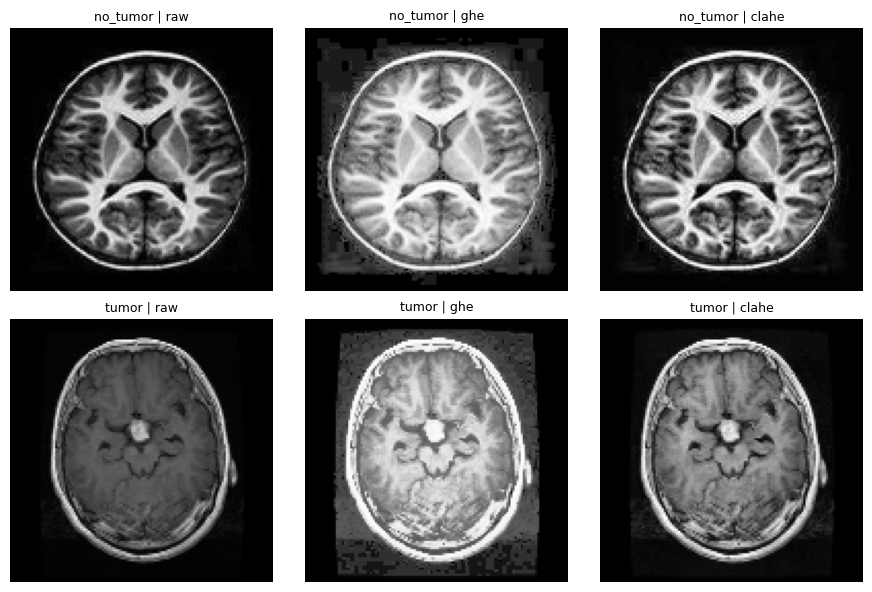

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
methods = ["raw", "ghe", "clahe"]

for row, class_name in enumerate(BINARY_CLASSES):
    sample = train_df[train_df["class_name"] == class_name].iloc[0]
    raw_img = read_image(sample["path"])
    imgs = [raw_img, apply_ghe(raw_img), apply_clahe(raw_img)]
    
    for col, (img, meth) in enumerate(zip(imgs, methods)):
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(f"{class_name} | {meth}", fontsize=9)
        axes[row, col].axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "v2_binary_preprocessing_samples.png", dpi=150)
plt.show()